# Cargar CSV en pandas

Este notebook carga el archivo CSV disponible en la carpeta del proyecto en un DataFrame de pandas.

In [7]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [12]:
# Ruta del archivo CSV
csv_path = Path("imputaciones-y-condenas-a-personas.csv")

# Cargar a DataFrame de pandas (con fallback de codificacion)
try:
    df = pd.read_csv(csv_path, sep=",", encoding="utf-8")
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, sep=",", encoding="latin1")

print(f"Archivo cargado: {csv_path}")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Archivo cargado: imputaciones-y-condenas-a-personas.csv
Filas: 122255 | Columnas: 19


In [9]:
# Vista previa de los datos
df.head()

,id_ncci,id_nunc,id_documento,Titulo_denuncia,depto_hechos,fecha_hecho,mes_primera_audi,fecha_primera_audi,fecha_resolución,edad,edad_tramos,sexo_persona,delito_imputado,delitos_agrupados,situación_procesal,delito_1,delito_2,delito_3,delito_4
0,65259fe81b747c5bf850a4d0285f109f,5d80fd27a6f284d2f0704e26dd65494e,a473c2e40ac3f3b2803fd2d7ee276ce6,HURTO,MONTEVIDEO,2017-11-01,2019-08,2019-08-14,2019-08-14,"36,0",36-45,M,HURTO,HURTO,SUSPENSION CONDICIONAL,HURTO,NaN,NaN,NaN
1,a57b0000d41f403eae7fb5a6c208f472,cbb57405725f99f5bd24e8a0c4fd20b1,852bf4b2517ee362ecefb419b5e1e7ff,LESIONES PERSONALES,MONTEVIDEO,2017-11-01,2019-03,2019-03-19,2019-03-19,"38,0",36-45,M,HOMICIDIO,HOMICIDIO,PROCESO ABREVIADO/ SIMPLIFICADO,HOMICIDIO,NaN,NaN,NaN
2,c6055dbbc381abb7b79781b4fcb67b9a,917a60406934e5276b51f504ebe8d873,28c4a81db66f7b2e3995e5a7f5a673ae,HURTO,MONTEVIDEO,2017-10-29,2020-06,2020-06-22,2020-06-22,"18,0",18-25,M,RECEPTACIÓN,OTROS DELITOS,PROCESO ABREVIADO/ SIMPLIFICADO,RECEPTACIÓN,NaN,NaN,NaN
3,909c4f4fea09b74cf788cd7e94ee7d1d,8332a330ab57c92aaaff58a7f3dd3f24,b31313f0b13d7011c730ef1b226f6429,ATENTADO VIOLENTO AL PUDOR,RIVERA,2017-11-01,2023-05,2023-05-03,2023-05-03,"41,0",36-45,M,ATENTADO VIOLENTO AL PUDOR,Delitos sexuales,PROCESO ABREVIADO/ SIMPLIFICADO,ATENTADO VIOLENTO AL PUDOR,NaN,NaN,NaN
4,2cd1030ef397b7cba4a594fb50f6eeae,4a4d10eded8945c32f403dfa594a2238,e3d6f98d8ccaf47c4b7d9f0940a25ea1,CHEQUES,MONTEVIDEO,2017-10-31,2020-09,2020-09-23,2020-09-23,"41,0",36-45,F,CHEQUES,CHEQUES,PROCESO ABREVIADO/ SIMPLIFICADO,CHEQUES,NaN,NaN,NaN


# ordenamiento de delitos por tipo

In [75]:
# Asegurar formato de fecha
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], errors='coerce')

# Filtrar filas con fecha, departamento y delito válidos
df_delitos_departamento = df.dropna(subset=['fecha_hecho', 'depto_hechos', 'delitos_agrupados']).copy()

# Dataset ordenado de forma descendente por numero de delitos
tipo_delitos_ordenados = (
    df_delitos_departamento.groupby('delitos_agrupados', as_index=False)
    .size()
    .rename(columns={'size': 'numero_delitos'})
    .sort_values('numero_delitos', ascending=False)
    .reset_index(drop=True)
)

# Agrupar por mes para ver evolución temporal
evolucion = (
    df_delitos_departamento
    .assign(periodo=df_delitos_departamento['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

print(f'Registros para análisis: {len(df_delitos_departamento)}')
tipo_delitos_ordenados.head(20)

Registros para análisis: 122226


,delitos_agrupados,numero_delitos
0,HURTO,40493
1,OTROS DELITOS,26426
2,ESTUPEFACIENTES,9520
3,RAPIÑA,8998
4,VIOLENCIA DOMÉSTICA,7039
5,DESACATO,6102
6,Armas de fuego y explosivos,4801
7,HOMICIDIO,3289
8,Delitos sexuales,3177
9,LESIONES PERSONALES,3117


In [ ]:
## Ordenamiento de delitos por departamento


In [76]:

# Dataset ordenado de forma descendente por numero de delitos por departamento
delitos_por_departamento = (
    df_delitos_departamento.groupby('depto_hechos', as_index=False)
    .size()
    .rename(columns={'size': 'numero_delitos'})
    .sort_values('numero_delitos', ascending=False)
    .reset_index(drop=True)
)

# Agrupar por mes para ver evolución temporal
evolucion = (
    df_delitos_departamento
    .assign(periodo=df_delitos_departamento['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

print(f'Registros para análisis: {len(df_delitos_departamento)}')
delitos_por_departamento

Registros para análisis: 122226


,depto_hechos,numero_delitos
0,MONTEVIDEO,43775
1,CANELONES,18305
2,MALDONADO,7478
3,SALTO,5832
4,CERRO LARGO,4933
5,RIVERA,4924
6,PAYSANDU,4592
7,SORIANO,4159
8,SAN JOSE,4149
9,COLONIA,3454


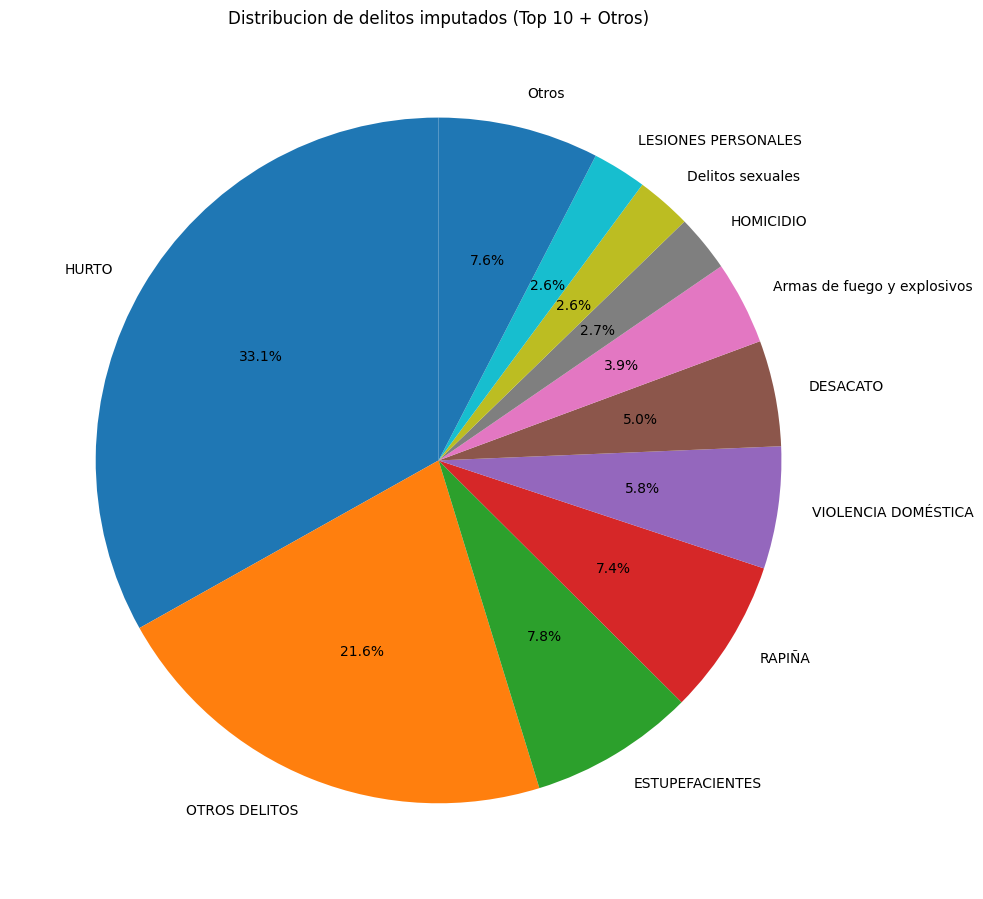

In [78]:
# Pie chart por delito imputado (Top 10 + Otros)
top10 = tipo_delitos_ordenados.head(10).copy()
otros = tipo_delitos_ordenados['numero_delitos'].iloc[10:].sum()

pie_data = top10[['delitos_agrupados', 'numero_delitos']].copy()
pie_data.loc[len(pie_data)] = ['Otros', otros]

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data['numero_delitos'],
    labels=pie_data['delitos_agrupados'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribucion de delitos imputados (Top 10 + Otros)')
plt.tight_layout()
plt.show()

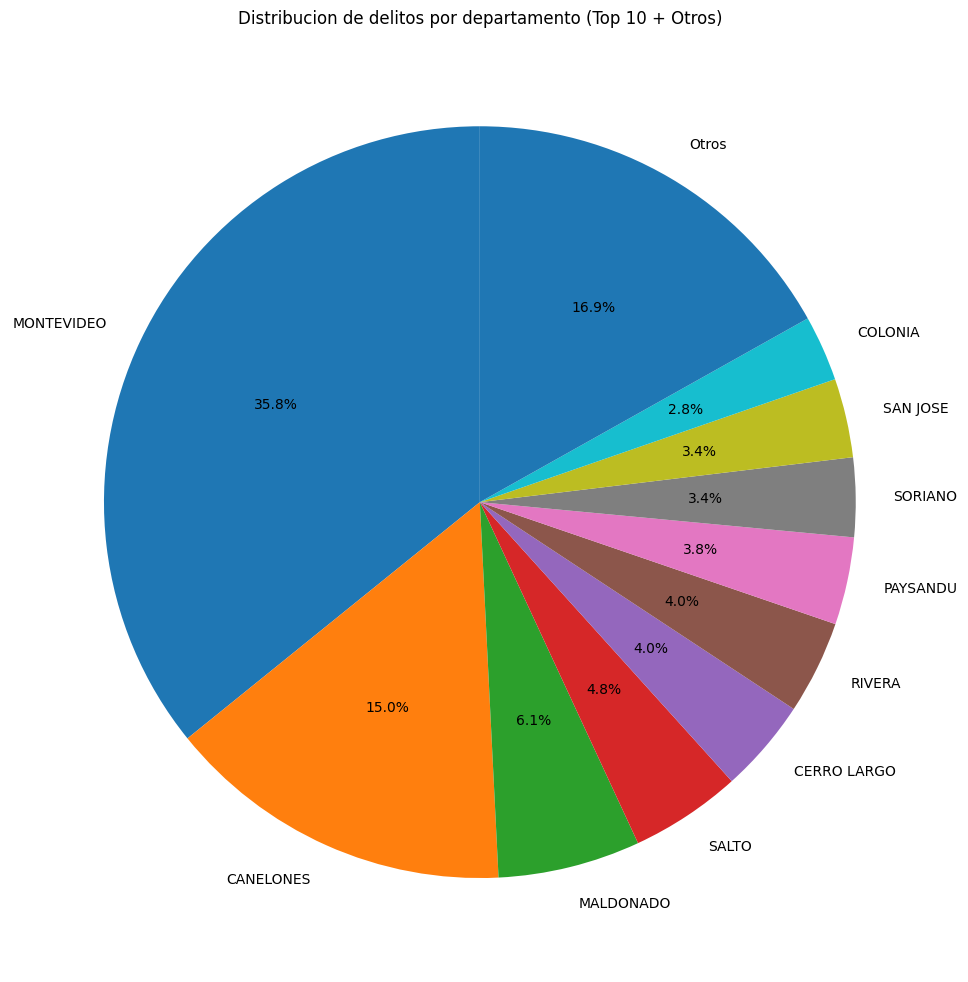

In [63]:
# Pie chart por departamento (Top 10 + Otros)
top10 = delitos_por_departamento.head(10).copy()
otros = delitos_por_departamento['numero_delitos'].iloc[10:].sum()

pie_data = top10[['depto_hechos', 'numero_delitos']].copy()
pie_data.loc[len(pie_data)] = ['Otros', otros]

plt.figure(figsize=(10, 10))
plt.pie(
    pie_data['numero_delitos'],
    labels=pie_data['depto_hechos'],
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribucion de delitos por departamento (Top 10 + Otros)')
plt.tight_layout()
plt.show()

## Evolución temporal de delito_imputado por depto_hechos
Se convierte `fecha_hecho` a fecha, se agrupa por mes/departamento/delito y se grafica la cantidad de casos en el tiempo.

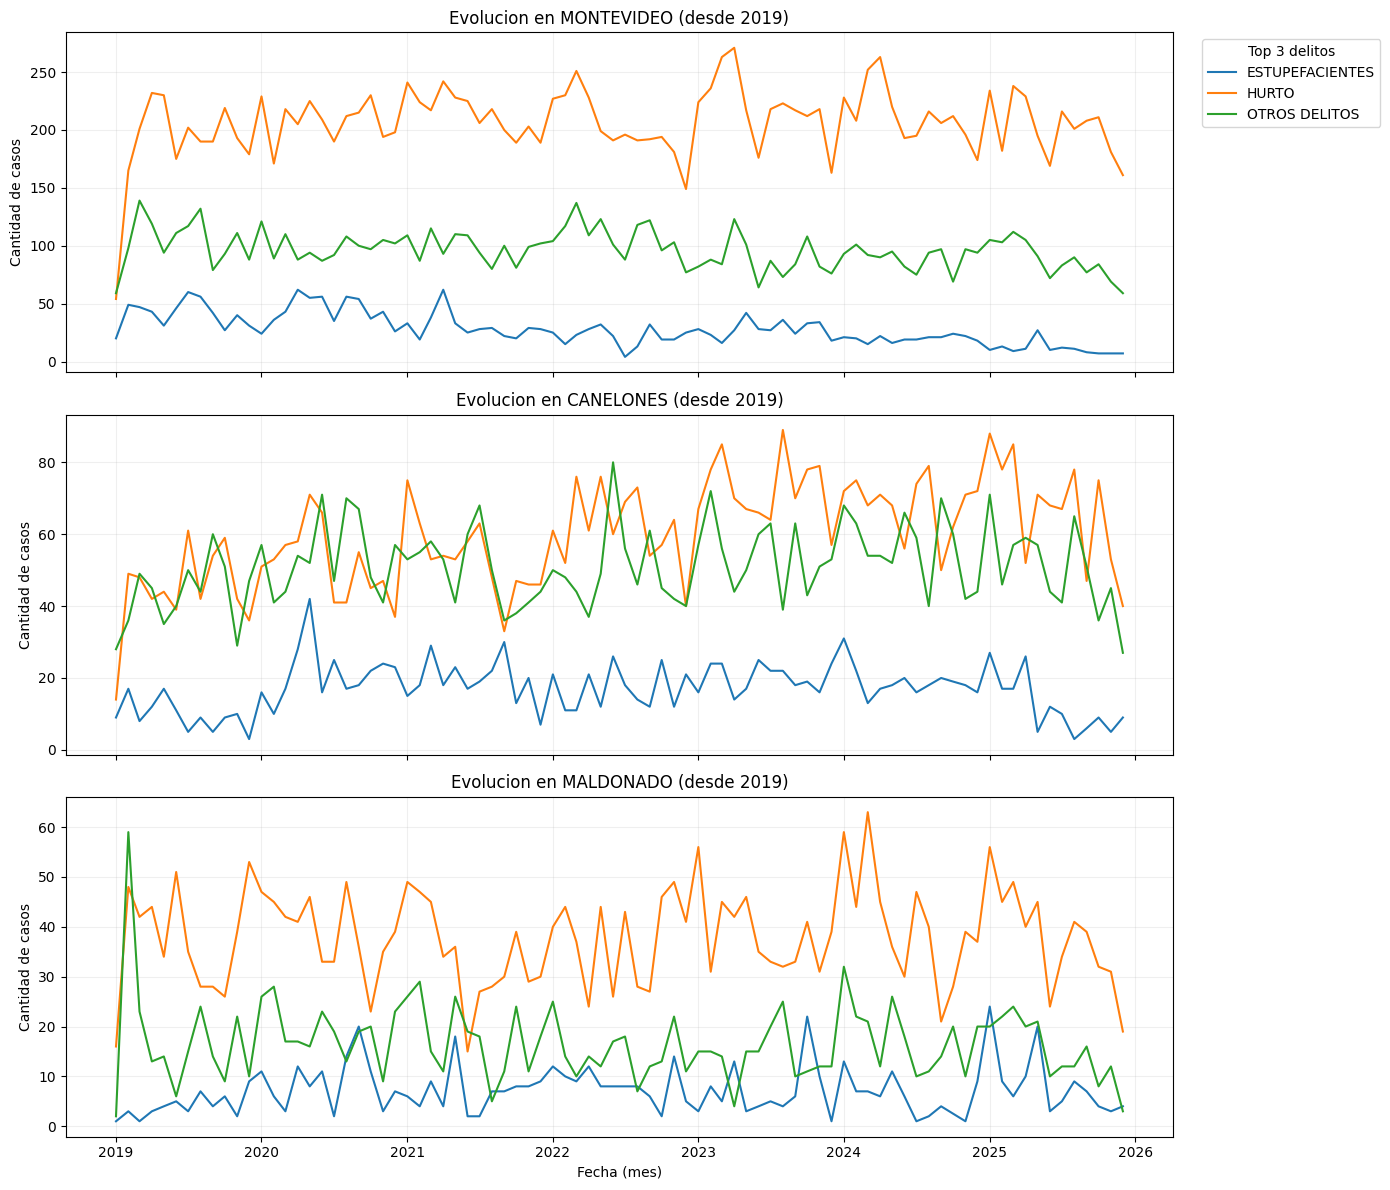

Top 3 delitos (desde 2019): ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES']
Top 3 departamentos (desde 2019): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']


In [79]:
# Top 3 delitos en Top 3 departamentos (filtrado desde 2019)
fecha_inicio = pd.Timestamp('2019-01-01')
base_2019 = df_delitos_departamento[df_delitos_departamento['fecha_hecho'] >= fecha_inicio].copy()

top3_delitos_2019 = (
    base_2019.groupby('delitos_agrupados', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['delitos_agrupados']
    .tolist()
)

top3_deptos_2019 = (
    base_2019.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

evolucion_2019 = (
    base_2019
    .assign(periodo=base_2019['fecha_hecho'].dt.to_period('M').dt.to_timestamp())
    .groupby(['periodo', 'depto_hechos', 'delitos_agrupados'], as_index=False)
    .size()
    .rename(columns={'size': 'cantidad'})
)

evolucion_top_2019 = evolucion_2019[
    evolucion_2019['delitos_agrupados'].isin(top3_delitos_2019) &
    evolucion_2019['depto_hechos'].isin(top3_deptos_2019)
]

fig, axes = plt.subplots(len(top3_deptos_2019), 1, figsize=(14, 12), sharex=True)
if len(top3_deptos_2019) == 1:
    axes = [axes]

for ax, depto in zip(axes, top3_deptos_2019):
    data_depto = evolucion_top_2019[evolucion_top_2019['depto_hechos'] == depto]
    for delito, grp in data_depto.groupby('delitos_agrupados'):
        grp = grp.sort_values('periodo')
        ax.plot(grp['periodo'], grp['cantidad'], label=delito)
    ax.set_title(f'Evolucion en {depto} (desde 2019)')
    ax.set_ylabel('Cantidad de casos')
    ax.grid(alpha=0.2)

axes[-1].set_xlabel('Fecha (mes)')
axes[0].legend(title='Top 3 delitos', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Top 3 delitos (desde 2019):', top3_delitos_2019)
print('Top 3 departamentos (desde 2019):', top3_deptos_2019)

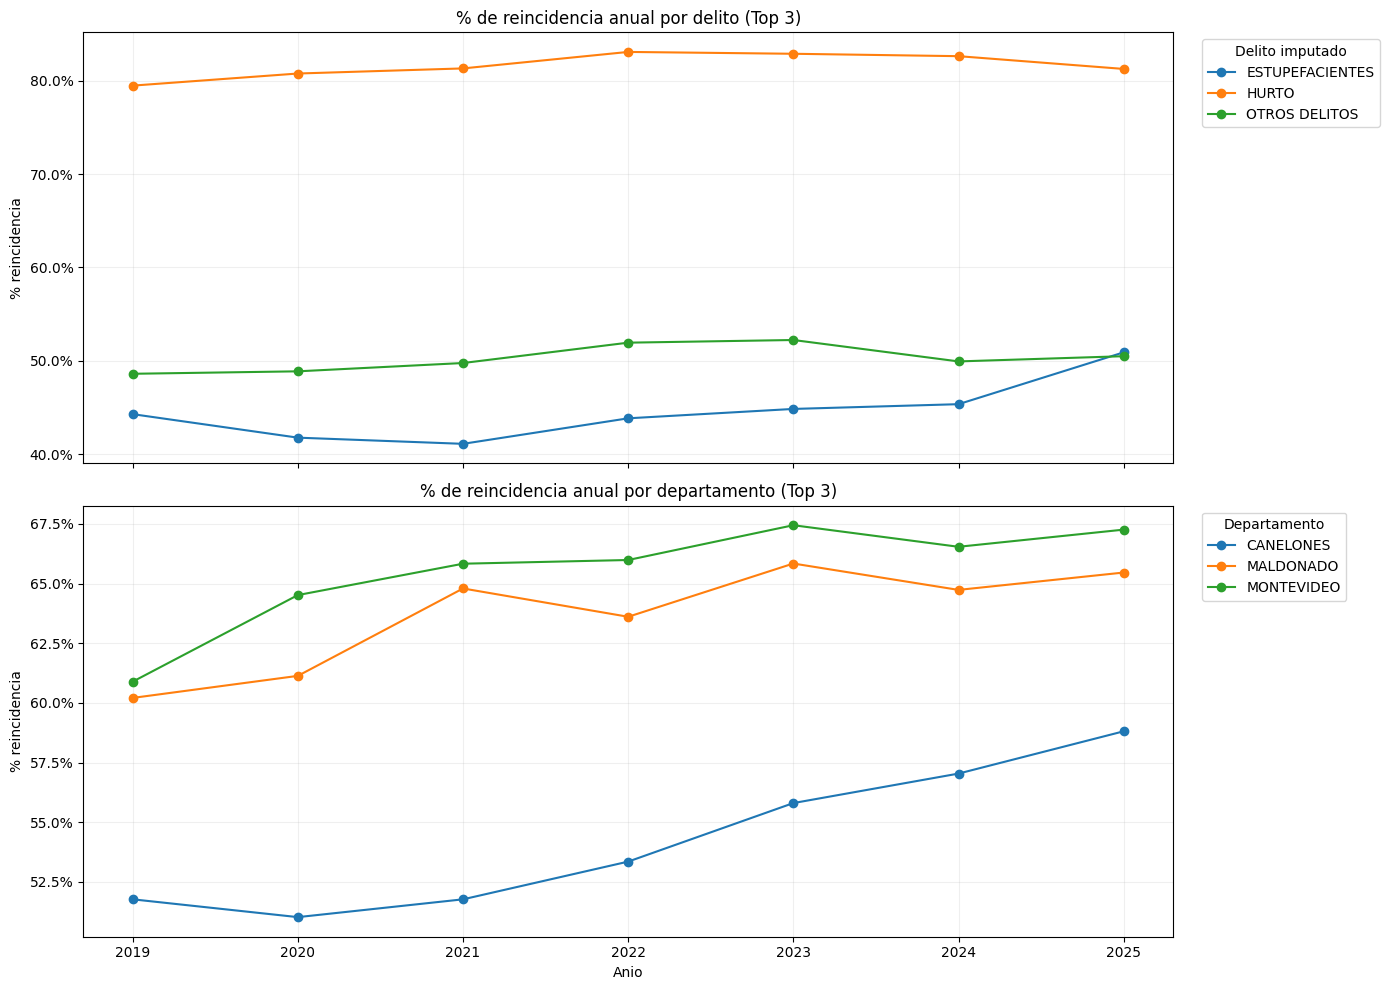

Top 3 delitos: ['HURTO', 'OTROS DELITOS', 'ESTUPEFACIENTES']
Top 3 departamentos: ['MONTEVIDEO', 'CANELONES', 'MALDONADO']
Cantidad de id_documento reincidentes globales: 23845

% reincidencia por delito (Top 3):


,delitos_agrupados,casos_totales,casos_reincidentes,pct_reincidencia
1,HURTO,39833,32548,81.711144
2,OTROS DELITOS,25280,12703,50.249209
0,ESTUPEFACIENTES,9345,4126,44.151953



% reincidencia por departamento (Top 3):


,depto_hechos,casos_totales,casos_reincidentes,pct_reincidencia
2,MONTEVIDEO,42265,27657,65.437123
1,MALDONADO,7299,4641,63.584053
0,CANELONES,17789,9668,54.348193


In [80]:
# % de reincidencia (top 5 delitos y top 5 departamentos) + evolucion anual
import matplotlib.ticker as mtick

# 1) IDs reincidentes en el dataset original (aparecen mas de 1 vez)
ids_reincidentes_global = (
    df.dropna(subset=['id_documento'])
    .groupby('id_documento')
    .size()
)
ids_reincidentes_global = ids_reincidentes_global[ids_reincidentes_global > 1].index

# 2) Base de analisis desde 2019 (para evitar sesgo por reincidencia previa a 2019)
fecha_inicio_rec = pd.Timestamp('2019-01-01')
base_analisis = df.dropna(subset=['id_documento', 'fecha_hecho', 'depto_hechos', 'delitos_agrupados']).copy()
base_analisis = base_analisis[base_analisis['fecha_hecho'] >= fecha_inicio_rec].copy()
base_analisis['es_reincidente_global'] = base_analisis['id_documento'].isin(ids_reincidentes_global)
base_analisis['anio'] = base_analisis['fecha_hecho'].dt.year

# 3) Top 3 delitos y top 3 departamentos por cantidad de casos
top3_delitos_rec = (
    base_analisis.groupby('delitos_agrupados', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['delitos_agrupados']
    .tolist()
)

top3_deptos_rec = (
    base_analisis.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

# 4) % de reincidencia por delito (top 3)
tabla_pct_delito = (
    base_analisis[base_analisis['delitos_agrupados'].isin(top3_delitos_rec)]
    .groupby('delitos_agrupados', as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
tabla_pct_delito['pct_reincidencia'] = (
    tabla_pct_delito['casos_reincidentes'] / tabla_pct_delito['casos_totales'] * 100
)
tabla_pct_delito = tabla_pct_delito.sort_values('pct_reincidencia', ascending=False)

# 5) % de reincidencia por departamento (top 3)
tabla_pct_depto = (
    base_analisis[base_analisis['depto_hechos'].isin(top3_deptos_rec)]
    .groupby('depto_hechos', as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
tabla_pct_depto['pct_reincidencia'] = (
    tabla_pct_depto['casos_reincidentes'] / tabla_pct_depto['casos_totales'] * 100
)
tabla_pct_depto = tabla_pct_depto.sort_values('pct_reincidencia', ascending=False)

# 6) Evolucion anual del % de reincidencia por delito (top 3)
evolucion_anual_delito = (
    base_analisis[base_analisis['delitos_agrupados'].isin(top3_delitos_rec)]
    .groupby(['anio', 'delitos_agrupados'], as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
evolucion_anual_delito['pct_reincidencia'] = (
    evolucion_anual_delito['casos_reincidentes'] / evolucion_anual_delito['casos_totales'] * 100
)

# 7) Evolucion anual del % de reincidencia por departamento (top 3)
evolucion_anual_depto = (
    base_analisis[base_analisis['depto_hechos'].isin(top3_deptos_rec)]
    .groupby(['anio', 'depto_hechos'], as_index=False)
    .agg(
        casos_totales=('id_documento', 'size'),
        casos_reincidentes=('es_reincidente_global', 'sum')
    )
)
evolucion_anual_depto['pct_reincidencia'] = (
    evolucion_anual_depto['casos_reincidentes'] / evolucion_anual_depto['casos_totales'] * 100
)

# 8) Graficos de evolucion anual
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for delito, grp in evolucion_anual_delito.groupby('delitos_agrupados'):
    grp = grp.sort_values('anio')
    axes[0].plot(grp['anio'], grp['pct_reincidencia'], marker='o', label=delito)
axes[0].set_title('% de reincidencia anual por delito (Top 3)')
axes[0].set_ylabel('% reincidencia')
axes[0].grid(alpha=0.2)
axes[0].legend(title='Delito imputado', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

for depto, grp in evolucion_anual_depto.groupby('depto_hechos'):
    grp = grp.sort_values('anio')
    axes[1].plot(grp['anio'], grp['pct_reincidencia'], marker='o', label=depto)
axes[1].set_title('% de reincidencia anual por departamento (Top 3)')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('% reincidencia')
axes[1].grid(alpha=0.2)
axes[1].legend(title='Departamento', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print('Top 3 delitos:', top3_delitos_rec)
print('Top 3 departamentos:', top3_deptos_rec)
print('Cantidad de id_documento reincidentes globales:', len(ids_reincidentes_global))

print('\n% reincidencia por delito (Top 3):')
display(tabla_pct_delito)

print('\n% reincidencia por departamento (Top 3):')
display(tabla_pct_depto)

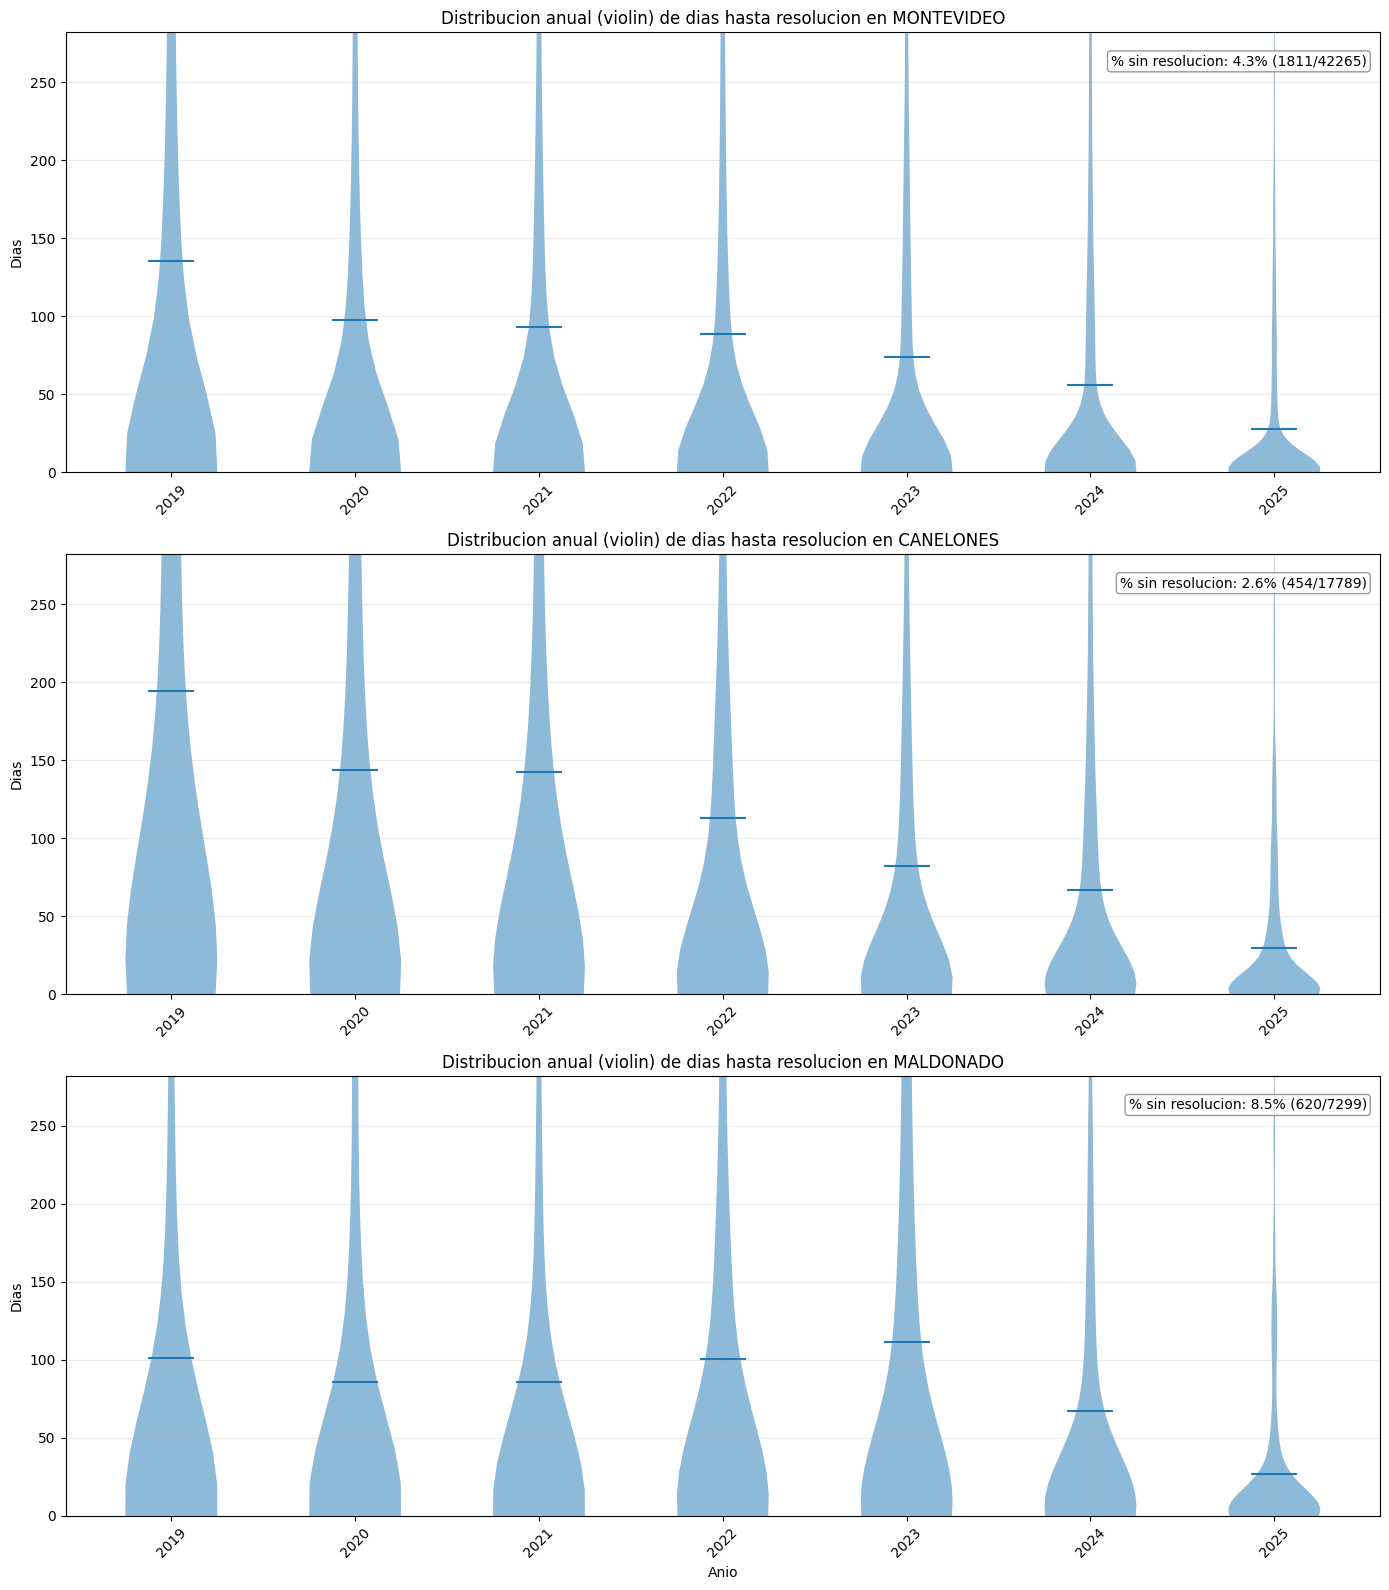

Limite superior eje Y (percentil 90): 282.0 dias
Top 3 departamentos (casos totales): ['MONTEVIDEO', 'CANELONES', 'MALDONADO']

% de casos sin resolucion por departamento:


,depto_hechos,casos_evaluados,casos_sin_resolucion,pct_sin_resolucion
2,MONTEVIDEO,42265,1811,4.284869
1,MALDONADO,7299,620,8.494314
0,CANELONES,17789,454,2.552139



Resumen anual (incluye casos evaluados y resueltos):


,anio,depto_hechos,promedio_dias,desvio_std_dias,n_casos_resueltos,casos_evaluados
2,2019,MONTEVIDEO,135.416308,287.531118,6034,6285
5,2020,MONTEVIDEO,97.284091,227.902803,6160,6406
8,2021,MONTEVIDEO,92.838759,216.620014,5898,6026
11,2022,MONTEVIDEO,88.597416,194.120017,5805,5980
14,2023,MONTEVIDEO,73.787446,150.415514,6022,6220
17,2024,MONTEVIDEO,56.022268,111.071861,5793,6058
20,2025,MONTEVIDEO,27.653026,59.050602,4692,5290
13,2023,MALDONADO,111.576327,187.911164,904,1007
1,2019,MALDONADO,101.516537,241.330362,1028,1048
10,2022,MALDONADO,100.812081,200.674195,894,981


In [81]:
# Tiempo entre fecha_hecho y fecha_resolucion por departamento (Top 3), promedio y desviacion estandar anual
import numpy as np

# Detectar columna de fecha de resolucion (puede variar por codificacion)
col_res_candidates = [c for c in df.columns if c.lower().startswith('fecha_resoluci')]
if not col_res_candidates:
    raise ValueError('No se encontro la columna de fecha_resolucion en el dataset.')
col_fecha_resolucion = col_res_candidates[0]

base_tiempo = df.copy()
base_tiempo['fecha_hecho'] = pd.to_datetime(base_tiempo['fecha_hecho'], errors='coerce')
base_tiempo[col_fecha_resolucion] = pd.to_datetime(base_tiempo[col_fecha_resolucion], errors='coerce')

# Base desde 2019 para calcular % sin resolucion
base_tiempo = base_tiempo.dropna(subset=['fecha_hecho', 'depto_hechos']).copy()
base_tiempo = base_tiempo[base_tiempo['fecha_hecho'] >= pd.Timestamp('2019-01-01')].copy()

# Top 3 departamentos por cantidad de casos totales (incluye sin resolucion)
top3_deptos_tiempo = (
    base_tiempo.groupby('depto_hechos', as_index=False)
    .size()
    .sort_values('size', ascending=False)
    .head(3)['depto_hechos']
    .tolist()
)

base_tiempo_top3 = base_tiempo[base_tiempo['depto_hechos'].isin(top3_deptos_tiempo)].copy()
base_tiempo_top3['anio'] = base_tiempo_top3['fecha_hecho'].dt.year

# % de casos sin resolucion por departamento
tabla_sin_res = (
    base_tiempo_top3.groupby('depto_hechos', as_index=False)
    .agg(
        casos_evaluados=(col_fecha_resolucion, 'size'),
        casos_sin_resolucion=(col_fecha_resolucion, lambda x: x.isna().sum())
    )
)
tabla_sin_res['pct_sin_resolucion'] = (
    tabla_sin_res['casos_sin_resolucion'] / tabla_sin_res['casos_evaluados'] * 100
)

# Filtrar registros resueltos y calcular dias transcurridos para el violin
base_resueltos = base_tiempo_top3.dropna(subset=[col_fecha_resolucion]).copy()
base_resueltos['dias_hasta_resolucion'] = (base_resueltos[col_fecha_resolucion] - base_resueltos['fecha_hecho']).dt.days
base_resueltos = base_resueltos[
    (base_resueltos['dias_hasta_resolucion'] >= 0) & (base_resueltos['dias_hasta_resolucion'] <= 3650)
]

# Casos evaluados por anio y departamento (incluye resueltos + no resueltos)
evaluados_anual = (
    base_tiempo_top3.groupby(['anio', 'depto_hechos'], as_index=False)
    .size()
    .rename(columns={'size': 'casos_evaluados'})
)

# Resumen anual de casos resueltos: promedio y desviacion estandar
resumen_anual_tiempo = (
    base_resueltos.groupby(['anio', 'depto_hechos'], as_index=False)
    .agg(
        promedio_dias=('dias_hasta_resolucion', 'mean'),
        desvio_std_dias=('dias_hasta_resolucion', 'std'),
        n_casos_resueltos=('dias_hasta_resolucion', 'size')
    )
)
resumen_anual_tiempo['desvio_std_dias'] = resumen_anual_tiempo['desvio_std_dias'].fillna(0)
resumen_anual_tiempo = resumen_anual_tiempo.merge(
    evaluados_anual,
    on=['anio', 'depto_hechos'],
    how='left'
 )

# Preparar anio para los graficos violin
base_resueltos['anio'] = base_resueltos['fecha_hecho'].dt.year

# Limite de eje Y usando percentil 90 para mejorar lectura
y_max = base_resueltos['dias_hasta_resolucion'].quantile(0.90)

# Grafico violin anual por departamento + % sin resolucion
fig, axes = plt.subplots(len(top3_deptos_tiempo), 1, figsize=(14, 16), sharex=False)
if len(top3_deptos_tiempo) == 1:
    axes = [axes]

for ax, depto in zip(axes, top3_deptos_tiempo):
    data_depto = base_resueltos[base_resueltos['depto_hechos'] == depto].copy()
    years = sorted(data_depto['anio'].dropna().unique())

    violin_data = [
        data_depto.loc[data_depto['anio'] == year, 'dias_hasta_resolucion'].values
        for year in years
    ]

    if len(violin_data) > 0 and sum(len(v) for v in violin_data) > 0:
        v = ax.violinplot(
            violin_data,
            positions=np.arange(1, len(years) + 1),
            showmeans=True,
            showextrema=False
        )
        for body in v['bodies']:
            body.set_alpha(0.5)

        ax.set_xticks(np.arange(1, len(years) + 1))
        ax.set_xticklabels(years, rotation=45)

    fila = tabla_sin_res[tabla_sin_res['depto_hechos'] == depto].iloc[0]
    pct_sin_res = fila['pct_sin_resolucion']
    casos_sin_res = int(fila['casos_sin_resolucion'])
    casos_eval = int(fila['casos_evaluados'])

    ax.set_title(f'Distribucion anual (violin) de dias hasta resolucion en {depto}')
    ax.set_ylabel('Dias')
    ax.set_ylim(0, y_max)
    ax.grid(alpha=0.25)
    ax.text(
        0.99, 0.95,
        f'% sin resolucion: {pct_sin_res:.1f}% ({casos_sin_res}/{casos_eval})',
        transform=ax.transAxes,
        ha='right',
        va='top',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='gray')
    )

axes[-1].set_xlabel('Anio')
plt.tight_layout()
plt.show()

print(f'Limite superior eje Y (percentil 90): {y_max:.1f} dias')
print('Top 3 departamentos (casos totales):', top3_deptos_tiempo)
print('\n% de casos sin resolucion por departamento:')
display(tabla_sin_res.sort_values('depto_hechos', ascending=False))

print('\nResumen anual (incluye casos evaluados y resueltos):')
resumen_anual_tiempo.sort_values(['depto_hechos', 'promedio_dias'], ascending=[False, False]).head(20)